
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

In [13]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt
import scipy
import matplotlib.animation as animation

## Solución

## Ejercicio 1

Para resolver la ecuación radial usamos el cambio $u(r)=rR(r)$.

En este caso el problema queda parecido a una ecuación de Schrödinger en una dimensión:

$$
-\frac{\hbar^2}{2\mu}\frac{d^2u(r)}{dr^2}
+\left(\frac{Q}{r}+\frac{l(l+1)\hbar^2}{2\mu r^2}\right)u(r)
=Eu(r)
$$

donde

$$
Q=-\frac{e^2}{4\pi\epsilon_0}
$$

Para el estado fundamental tenemos $l=0$, por lo que el término centrífugo se elimina. Así, usamos el potencial de Coulomb para construir la matriz del problema.

## Método de diferencias finitas

La segunda derivada se aproxima usando diferencias finitas centrales:

$$
\frac{d^2u(r)}{dr^2}
\approx
\frac{u(r+\Delta r)+u(r-\Delta r)-2u(r)}
{(\Delta r)^2}
$$

Con esto podemos escribir el problema como un sistema de autovalores. Se divide el intervalo radial en varios puntos y se construye la matriz correspondiente.

## Discretización

Tomamos $r_i$ como los puntos de la malla y $u_i=u(r_i)$. La matriz que se obtiene tiene una diagonal principal y dos diagonales secundarias.

Después de construir la matriz, usamos los autovalores y autovectores para encontrar los niveles de energía y las funciones de onda.


## Discretización y problema de autovalores

Para llevar la ecuación al código, dividimos el espacio radial en varios puntos $r_i$.
De esta forma tenemos:

$$
u(r_i)=u_i
$$

y el potencial evaluado en cada punto es $U(r_i)=U_i$.

La segunda derivada se aproxima mediante diferencias finitas:

$$
\frac{d^2u}{dr^2}\approx
\frac{u_{i+1}-2u_i+u_{i-1}}{(\Delta r)^2}
$$

Al reemplazar esta expresión en la ecuación radial y multiplicar por el factor

$$
k=\frac{2\mu(\Delta r)^2}{\hbar^2}
$$

obtenemos la ecuación que vamos a usar para construir la matriz:

$$
-(u_{i+1}+u_{i-1}-2u_i)+kU_i u_i=kEu_i
$$

Para los estados $s$, donde $l=0$, el potencial queda simplemente como

$$
U_i=-\frac{e^2}{4\pi\epsilon_0}\frac{1}{r_i}.
$$

De esta manera el problema se puede escribir como un problema de autovalores:

$$
H\vec{u}=E\vec{u}.
$$

Los autovalores corresponden a las energías permitidas y los autovectores nos dan las funciones de onda radiales.

##  Construcción de la matriz Hamiltoniana

A partir de la ecuación anterior podemos ordenar los términos para obtener la matriz que representa el Hamiltoniano.

Para una malla pequeña, tomando los puntos interiores $r_1,r_2,r_3$, tenemos:

$$
\frac{1}{k}
\begin{bmatrix}
2+kU_1 & -1 & 0\\
-1 & 2+kU_2 & -1\\
0 & -1 & 2+kU_3
\end{bmatrix}
\begin{pmatrix}
u_1\\
u_2\\
u_3
\end{pmatrix}
=
E
\begin{pmatrix}
u_1\\
u_2\\
u_3
\end{pmatrix}.
$$

Aquí aparece una matriz **tridiagonal**, que es justamente la estructura que construimos en el código.

Para los extremos usamos las condiciones de frontera:

$$
u(0)=0
$$

y, para una caja suficientemente grande,

$$
u(L)=0.
$$

Así, los puntos de los extremos no hacen parte de la matriz interior.

En el código se construye la diagonal principal con

$$
H_{ii}=\frac{2+kU_i}{k}
$$

y las diagonales secundarias con

$$
H_{i,i-1}=H_{i-1,i}=-\frac{1}{k}.
$$

Después de construir $H$, calculamos sus autovalores y autovectores. Los primeros autovalores nos dan los estados de menor energía del átomo de hidrógeno.


In [14]:
# Parámetros que se va a usar
L = 60      # Tamaño de la caja
hbar = 1.0
m = 1.0

N = 500        # Número de puntos
r_grid = np.linspace(0, L, N)
dr = r_grid[1] - r_grid[0]
dr2 = dr * dr

# Calculamos el factor k
k = (2.0 * m * dr2) / (hbar**2)

# Dejamos solo los puntos interiores
r = r_grid[1:-1]
N_int = len(r)

# Inicializamos la matriz
H = np.zeros((N_int, N_int))

# Llenamos la matriz
for i in range(N_int):
    U_i = -1.0 / r[i]  # Potencial de Coulomb
    
    # Diagonal principal
    H[i, i] = (2.0 + k * U_i) / k
    
    # Diagonales de los lados
    if i > 0:
        H[i, i - 1] = -1.0 / k
        H[i - 1, i] = -1.0 / k

# Resolvemos el problema de autovalores
E, psi = np.linalg.eigh(H)

print("Primeros 3 niveles de energía (Hartrees):", E[:3])

Primeros 3 niveles de energía (Hartrees): [-0.49820573 -0.12488725 -0.05553326]


Trapezoidal Area: 0.11991394853963885


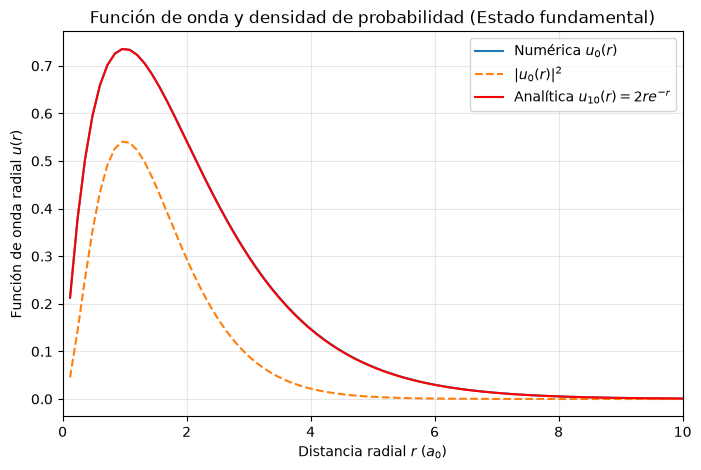

In [15]:


# Tomamos el estado fundamental
u_num = psi[:, 0]

# Corregimos el signo para que quede positivo
if u_num[np.argmax(np.abs(u_num))] < 0:
    u_num = -u_num

# Normalizamos
# Comprobamos la normalización
area_trap = np.trapezoid(u_num**2, x=r)
print(f"Trapezoidal Area: {area_trap}")

# Normalizamos la función
u_norm = u_num / np.sqrt(area_trap)

# Solución analítica para n=1
u_analitica = 2.0 * r * np.exp(-r)

# Graficamos el resultado
plt.figure(figsize=(8, 5))
plt.plot(r, u_norm, label=r'Numérica $u_0(r)$')
plt.plot(r, u_norm**2, linestyle="--", label=r'$|u_0(r)|^2$')
plt.plot(
    r, u_analitica, 'r-', linewidth=1.5, label=r'Analítica $u_{10}(r) = 2re^{-r}$'
)

plt.xlabel(r'Distancia radial $r$ ($a_0$)')
plt.ylabel(r'Función de onda radial $u(r)$')
plt.title('Función de onda y densidad de probabilidad (Estado fundamental)')
plt.legend()
plt.xlim(0, 10)  # Acercamiento a los primeros 10 radios de Bohr
plt.grid(True, alpha=0.3)
plt.show()

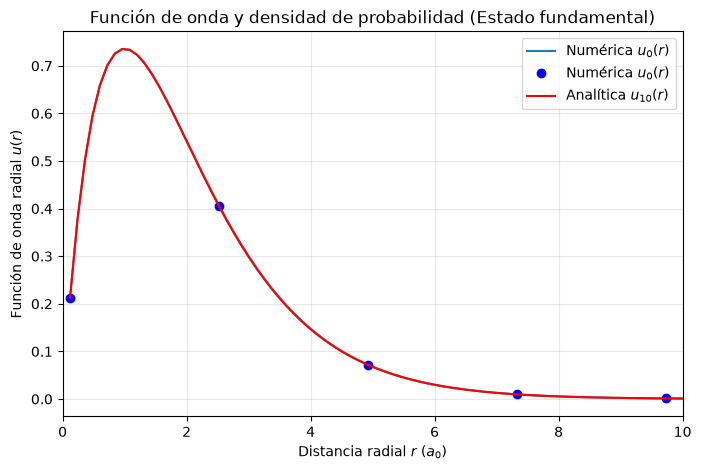

In [16]:
# Graficamos el resultado
n=20
plt.figure(figsize=(8, 5))
plt.plot(r, u_norm, label=r'Numérica $u_0(r)$')
plt.plot(r[::n], u_norm[::n], 'bo', label=r'Numérica $u_0(r)$')
plt.plot(r, u_analitica, 'r-', label=r'Analítica $u_{10}(r)$')

plt.xlabel(r'Distancia radial $r$ ($a_0$)')
plt.ylabel(r'Función de onda radial $u(r)$')
plt.title('Función de onda y densidad de probabilidad (Estado fundamental)')
plt.legend()
plt.xlim(0, 10)  # Acercamiento a los primeros 10 radios de Bohr
plt.grid(True, alpha=0.3)
plt.show()

#### Densidad de probabilidad radial para el átomo de Hidrogeno  

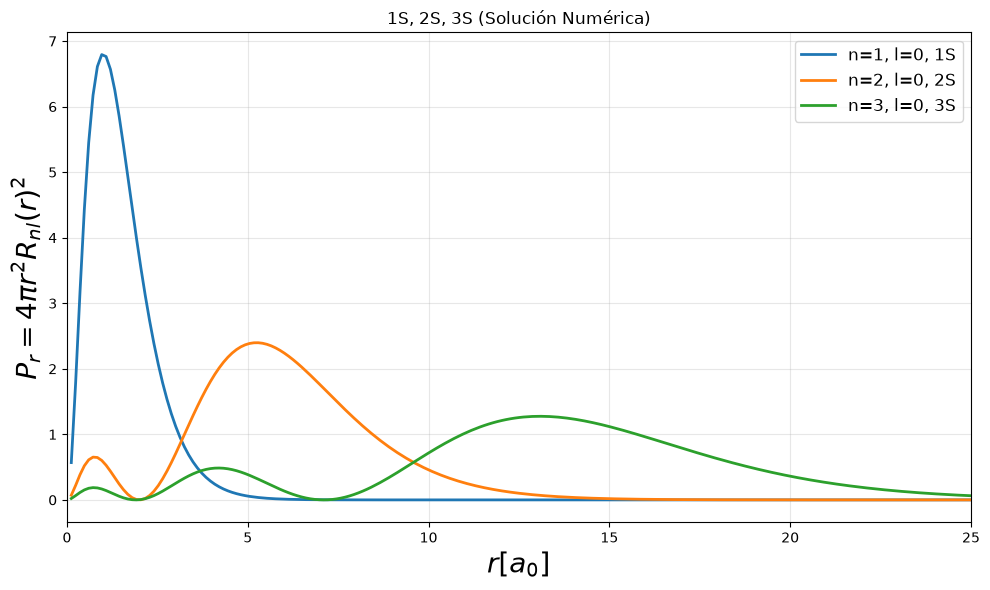

In [17]:


fig, ax = plt.subplots(figsize=(10, 6))

# Estados que vamos a mostrar
estados = ['1S', '2S', '3S']

# Tomamos los primeros 3 estados
for n in range(3):
    # Sacamos el autovector
    u_n = psi[:, n]
    
    # Ajustamos el signo
    if u_n[np.argmax(np.abs(u_n))] < 0:
        u_n = -u_n
        
    # Normalizamos
    area = np.trapezoid(u_n**2, x=r)
    u_norm = u_n / np.sqrt(area)
    
    # Calculamos la densidad
    P_r = 4 * np.pi * u_norm**2
    
    # Graficamos
    ax.plot(r, P_r, lw=2, label=f'n={n+1}, l=0, {estados[n]}')

# Ajustamos la gráfica
ax.set_xlabel(r'$r [a_0]$', fontsize=20)
ax.set_ylabel(r'$P_r = 4\pi r^2 R_{nl}(r)^2$', fontsize=20)
ax.set_title('1S, 2S, 3S (Solución Numérica)')
ax.set_xlim(0, 25) # Vista hasta 25 radios de Bohr
ax.legend(fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Representación de los orbitales

En esta parte usamos los primeros estados del átomo de hidrógeno para representar la densidad de probabilidad en el plano $xz$.

Para cada combinación de $n$ y $l$ calculamos primero la parte radial y después la parte angular de la función de onda.

La densidad que mostramos es

$$
|\psi_{nl}|^2.
$$

Para que las zonas con menor densidad también sean visibles, usamos una escala no lineal en la intensidad de la imagen. Esto permite distinguir mejor los lóbulos y los nodos de los orbitales.

Además, se dejan marcados los estados que no son posibles, como $1p$ y $1d$, porque para un nivel $n$ siempre debe cumplirse

$$
l<n.
$$


**Nota**: El siguiente código fue con ayuda de la IA para que se visualizará mejor las regiones

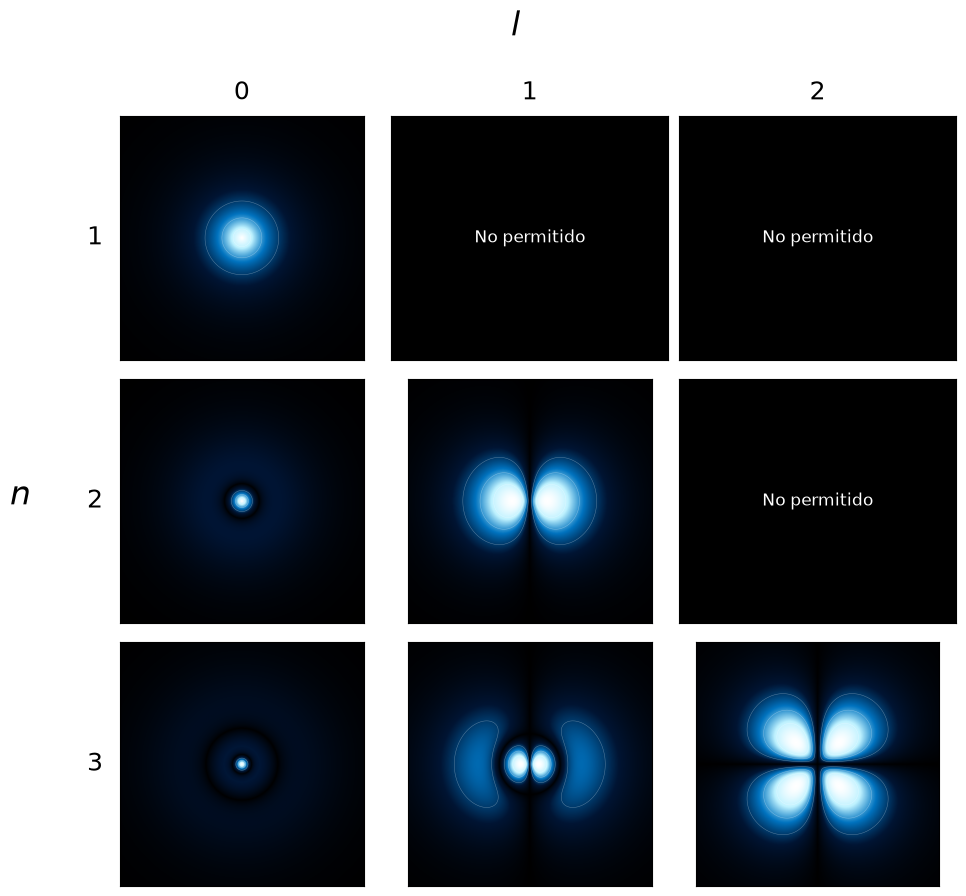

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import genlaguerre
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

# Creamos el mapa de colores
colores = [(0, 0, 0), (0, 0.08, 0.20), (0, 0.45, 0.75), (0.75, 0.95, 1), (1, 1, 1)]
cmap_cyan = LinearSegmentedColormap.from_list("orbital_cyan", colores)


# Función para calcular la densidad del orbital
def densidad_orbital(n, l, limite, puntos=500):
    # Creamos la malla
    x = np.linspace(-limite, limite, puntos)
    z = np.linspace(-limite, limite, puntos)
    X, Z = np.meshgrid(x, z)

    # Distancia al núcleo
    R = np.sqrt(X**2 + Z**2)
    R_seguro = np.where(R == 0, 1e-12, R)

    # Variable radial
    rho = 2.0 * R_seguro / n

    # Parte radial
    laguerre = genlaguerre(n - l - 1, 2 * l + 1)
    parte_radial = (rho**l) * np.exp(-rho / 2.0) * laguerre(rho)

    # Parte angular
    if l == 0:
        parte_angular = np.ones_like(R)

    elif l == 1:
        # Orbital p_x
        parte_angular = X / R_seguro

    elif l == 2:
        # Orbital d_xz
        parte_angular = (X * Z) / R_seguro**2

    # Función de onda
    psi = parte_radial * parte_angular

    # Densidad de probabilidad
    densidad = np.abs(psi)**2

    # Normalizamos para comparar todos los orbitales
    densidad /= np.max(densidad)

    return x, z, densidad


# Configuramos la figura
fig, axes = plt.subplots(3, 3, figsize=(11, 10), facecolor="white")
plt.subplots_adjust(wspace=0.04, hspace=0.08)

# Límites para cada nivel
limites_n = [5, 14, 24]

# Niveles y valores de l
niveles = [1, 2, 3]
valores_l = [0, 1, 2]

# Generamos las gráficas
for fila, n in enumerate(niveles):
    for col, l in enumerate(valores_l):

        ax = axes[fila, col]

        # Revisamos si el estado existe
        if l >= n:
            ax.set_facecolor("black")
            ax.text(
                0.5, 0.5, "No permitido",
                transform=ax.transAxes,
                ha="center", va="center",
                color="white", fontsize=12
            )

        else:
            x, z, densidad = densidad_orbital(n, l, limites_n[fila])

            # Usamos una escala de potencia para que se puedan ver
            # mejor las zonas donde la densidad es pequeña
            ax.imshow(
                densidad,
                extent=[x.min(), x.max(), z.min(), z.max()],
                origin="lower",
                cmap=cmap_cyan,
                norm=PowerNorm(gamma=0.35, vmin=0, vmax=1),
                interpolation="bilinear",
                aspect="equal"
            )

            # Añadimos algunas curvas para marcar mejor los lóbulos
            ax.contour(
                x, z, densidad,
                levels=[0.05, 0.20, 0.50],
                colors="white",
                linewidths=0.35,
                alpha=0.35
            )

        # Quitamos los ejes
        ax.set_xticks([])
        ax.set_yticks([])

        # Nombre de l arriba
        if fila == 0:
            ax.set_title(f"{l}", fontsize=18, pad=12)

        # Nombre de n a la izquierda
        if col == 0:
            ax.set_ylabel(
                f"{n}",
                fontsize=18,
                rotation=0,
                labelpad=18,
                va="center"
            )

# Títulos generales
fig.text(0.5, 0.96, r"$l$", ha="center", fontsize=24,
         fontweight="bold", style="italic")

fig.text(0.04, 0.5, r"$n$", va="center", fontsize=24,
         fontweight="bold", style="italic")

plt.show()
